In [1]:
%%duckdb


SELECT 
  *, date_diff('minute', start_at, stop_at) AS duration_min
FROM (
  SELECT 
    * EXCLUDE (tripduration, starttime, stoptime),
    strptime(starttime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS start_at,
    strptime(stoptime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS stop_at
  FROM 's3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet'
)
LIMIT 3

,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender,start_at,stop_at,duration_min
0,455,1 Ave & E 44 St,40.750020,-73.969053,265,Stanton St & Chrystie St,40.722293,-73.991475,18660,Subscriber,1960.0,2,2015-01-01 00:01:00,2015-01-01 00:24:00,23
1,434,9 Ave & W 18 St,40.743174,-74.003664,482,W 15 St & 7 Ave,40.739355,-73.999318,16085,Subscriber,1963.0,1,2015-01-01 00:02:00,2015-01-01 00:08:00,6
2,491,E 24 St & Park Ave S,40.740964,-73.986022,505,6 Ave & W 33 St,40.749013,-73.988484,20845,Subscriber,1974.0,1,2015-01-01 00:04:00,2015-01-01 00:10:00,6


## Problem 1: Trip duration

### Part 1: Build a Regression Model

Build a regression to predict trip duration by using
- Day of time
- Distance between start and end stations (there might be more than one way to measure it)
- Hour of day
- Weekend indicator
- Don't forget to model bias (this one is intentionally not used in lecture)
- Also any thing you want to end

### Part 2: Experiment Design

- Ensure that you properly design your experiment to report unbiased performance metric you choose

### Part 3 [Optional]: Visualize

- Generate some fictional pickup and dropoff locations for bike trips (random pair selection)
- Estimate trip duration for those say 10 trips
- Visualize them on map using `pydeck` by using redish color for slower trips and greener for faster trips.

### PART 1

Modelleme için temiz `trips` tablosu kurulur; alanlar yeniden adlandırılır, süre dakikaya çevrilir ve aykırı kayıtlar (1 120 dk dışı süreler, NYC sınırları dışındaki koordinatlar) elenir.

In [2]:
%%duckdb

CREATE OR REPLACE TABLE trips AS
SELECT
    "start station id"        AS start_id,
    "end station id"          AS end_id,
    "start station latitude"  AS start_lat,
    "start station longitude" AS start_lon,
    "end station latitude"    AS end_lat,
    "end station longitude"   AS end_lon,
    usertype,
    start_at, stop_at,
    date_diff('minute', start_at, stop_at) AS duration_min
FROM (
    SELECT * EXCLUDE (tripduration, starttime, stoptime),
        strptime(starttime, ['%m/%d/%Y %H:%M','%m/%d/%Y %H:%M:%S','%Y-%m-%d %H:%M:%S']) AS start_at,
        strptime(stoptime,  ['%m/%d/%Y %H:%M','%m/%d/%Y %H:%M:%S','%Y-%m-%d %H:%M:%S']) AS stop_at
    FROM 's3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet'
)
WHERE date_diff('minute', start_at, stop_at) BETWEEN 1 AND 120
  AND "start station latitude"  BETWEEN 40.4 AND 41.0
  AND "start station longitude" BETWEEN -74.3 AND -73.6
  AND "end station latitude"    BETWEEN 40.4 AND 41.0
  AND "end station longitude"   BETWEEN -74.3 AND -73.6;

SELECT COUNT(*) AS rows FROM trips;

,rows
0,23682653


İstasyon Koordinatlarının Çıkarılması

`trips` tablosundaki tüm başlangıç ve bitiş istasyonları `UNION ALL` ile birleştirilip
her istasyon için **ortalama (lat, lon)** hesaplanır.

Aynı istasyon farklı trip kayıtlarında küçük GPS sapmaları içerebileceğinden
`AVG()` ile tek bir temsil koordinatı elde edilir.

Sonuç, **683 benzersiz istasyonu** içeren `stations` DataFrame'i olarak Python'a aktarılır;
bu tablo sonraki adımda OSMnx yol ağı üzerinde istasyonlar arası mesafe hesabında kullanılacaktır.


In [3]:
%%duckdb -o stations -t df

SELECT station_id, AVG(lat) AS lat, AVG(lon) AS lon
FROM (
    SELECT start_id AS station_id, start_lat AS lat, start_lon AS lon FROM trips
    UNION ALL
    SELECT end_id, end_lat, end_lon FROM trips
)
WHERE station_id IS NOT NULL
GROUP BY station_id

,station_id,lat,lon
0,72,40.767272,-73.993929
1,79,40.719116,-74.006667
2,82,40.711174,-74.000165
3,83,40.683826,-73.976323
4,116,40.741776,-74.001497
...,...,...,...
678,3435,40.718822,-73.995960
679,3436,40.721319,-74.010065
680,3438,40.772249,-73.958421
681,3439,40.740343,-73.989551


Yol ağı üzerinden mesafe hesabı için `osmnx` kütüphanesi kurulur.

**Amaç:** Gerçek bisiklet yol ağını indirip rota mesafesi çıkarabilmek.

In [4]:
pip install osmnx

Note: you may need to restart the kernel to use updated packages.


OSMnx ile NYC bisiklet yol ağı indirilir, her istasyon en yakın düğüme eşlenir ve Dijkstra ile istasyonlar arası gerçek ağ mesafesi (km) hesaplanıp parquet'e kaydedilir (varsa cache okunur).

In [5]:
# pip install osmnx   (ortamda yoksa)
import os, osmnx as ox, networkx as nx, pandas as pd

OUT = "station_network_km.parquet"
if os.path.exists(OUT):
    print("cache mevcut:", OUT)
else:
    st = stations            # önceki hücreden -o ile gelen DataFrame
    print(f"{len(st)} istasyon route edilecek")

    pad = 0.02
    # OSMnx v2: bbox = (west, south, east, north)
    bbox = (st.lon.min()-pad, st.lat.min()-pad, st.lon.max()+pad, st.lat.max()+pad)
    G = ox.graph_from_bbox(bbox=bbox, network_type="bike")

    st = st.copy()
    st["node"] = ox.distance.nearest_nodes(G, st.lon.values, st.lat.values)
    node_of = dict(zip(st.station_id, st.node))

    # Kaynak-bazlı Dijkstra: her istasyondan tüm hedeflere (yönlü graf -> tek yönler doğru)
    rows = []
    for sid, src in node_of.items():
        dist = nx.single_source_dijkstra_path_length(G, src, weight="length")
        rows += [(sid, did, dist[dst] / 1000.0) for did, dst in node_of.items() if dst in dist]

    pd.DataFrame(rows, columns=["start_id", "end_id", "network_km"]).to_parquet(OUT)
    print(f"{len(rows):,} istasyon çifti -> {OUT}")

cache mevcut: station_network_km.parquet


`trip_features` görünümü kurulur; hedef değişken süre (y) ile öznitelikler tanımlanır: ağ mesafesi, saatin sin/cos kodlaması, hafta sonu ve gün, kullanıcı tipi.

**Amaç:** Regresyon modelinin okuyacağı öznitelik tablosunu oluşturmak.

In [6]:
%%duckdb


CREATE OR REPLACE VIEW trip_features AS
SELECT
    duration_min::DOUBLE                                  AS y,
    p.network_km                                          AS dist_km,
    sin(2*pi()*hour(start_at)/24.0)                       AS hour_sin,
    cos(2*pi()*hour(start_at)/24.0)                       AS hour_cos,
    (isodow(start_at) >= 6)::INT::DOUBLE                  AS is_weekend,
    (isodow(start_at) = 2)::INT::DOUBLE                   AS d_tue,
    (isodow(start_at) = 3)::INT::DOUBLE                   AS d_wed,
    (isodow(start_at) = 4)::INT::DOUBLE                   AS d_thu,
    (isodow(start_at) = 5)::INT::DOUBLE                   AS d_fri,
    (isodow(start_at) = 6)::INT::DOUBLE                   AS d_sat,
    (isodow(start_at) = 7)::INT::DOUBLE                   AS d_sun,
    (COALESCE(t.usertype,'Subscriber') = 'Customer')::INT::DOUBLE AS is_customer
FROM trips t
JOIN 'station_network_km.parquet' p
  ON t.start_id = p.start_id AND t.end_id = p.end_id;

SELECT * FROM trip_features LIMIT 5;

,y,dist_km,hour_sin,hour_cos,is_weekend,d_tue,d_wed,d_thu,d_fri,d_sat,d_sun,is_customer
0,23.0,4.019703,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,6.0,0.781789,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,6.0,1.341775,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,3.0,0.667773,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,16.0,2.859294,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


Toplam yolculuk sayısı ile rota mesafesi bulunabilen (öznitelikleştirilen) yolculuk sayısı karşılaştırılır.

**Amaç:** JOIN sonrası veri kaybını / kapsama oranını doğrulamak.

In [7]:
%%duckdb
SELECT
  (SELECT COUNT(*) FROM trips)          AS trips_all,
  (SELECT COUNT(*) FROM trip_features)  AS trips_routed;

,trips_all,trips_routed
0,23682653,23411755


**Ne yapılıyor:** OLS için gereken X'X ve X'y toplamlarını hesaplayan SQL dinamik olarak üretilip DuckDB'de çalıştırılır.

**Amaç:** Milyonlarca satırı belleğe almadan tek bir aggregate sorgusuyla normal denklem bileşenlerini çıkarmak.

In [8]:
FEAT = ["dist_km", "hour_sin", "hour_cos", "is_weekend",
        "d_tue", "d_wed", "d_thu", "d_fri", "d_sat", "d_sun", "is_customer"]
COLS = ["bias"] + FEAT

select_cols = ["1.0 AS bias"] + [f"{c}::DOUBLE AS {c}" for c in FEAT] + ["y::DOUBLE AS y"]
agg_exprs = [
    "COUNT(*)::DOUBLE AS n",
    "SUM(y)::DOUBLE AS y_sum",
    "SUM(y * y)::DOUBLE AS y_y",
]

# XtX = X'X icin tum feature-feature carpim toplamlari
for i, a in enumerate(COLS):
    for b in COLS[i:]:
        agg_exprs.append(f"SUM({a} * {b})::DOUBLE AS {a}__{b}")

# Xty = X'y icin feature-target carpim toplamlari
for c in COLS:
    agg_exprs.append(f"SUM({c} * y)::DOUBLE AS {c}__y")

select_sql = ",\n        ".join(select_cols)
agg_sql = ",\n    ".join(agg_exprs)

sql = f"""
WITH x AS (
    SELECT
        {select_sql}
    FROM trip_features
)
SELECT
    {agg_sql}
FROM x
"""

# DuckDB magic ayni notebook DuckDB oturumundaki trip_features view'ini gorur.
# Python tarafina sadece tek satirlik aggregate tablosu gelir.
get_ipython().run_cell_magic("duckdb", "-o ols_stats -t df", sql)

,n,y_sum,y_y,bias__bias,bias__dist_km,bias__hour_sin,bias__hour_cos,bias__is_weekend,bias__d_tue,bias__d_wed,...,hour_sin__y,hour_cos__y,is_weekend__y,d_tue__y,d_wed__y,d_thu__y,d_fri__y,d_sat__y,d_sun__y,is_customer__y
0,23411755.0,317316929.0,7.087810e+09,23411755.0,5.267779e+07,-5.801608e+06,-7.673394e+06,5440342.0,3577524.0,3783375.0,...,-8.863832e+07,-1.113154e+08,84113802.0,45795465.0,48726062.0,47647110.0,46300377.0,42918763.0,41195039.0,63914312.0


**Ne yapılıyor:** Aggregate özetlerden X'X ve X'y matrisleri kurulur ve `lstsq` ile regresyon katsayıları (beta) çözülür.

**Amaç:** Kapalı-form normal denklemi çözerek modeli eğitmek.

In [9]:
import numpy as np


def matrices_from_aggregates(stats):
    """Tek satirlik aggregate tablosundan XtX, Xty ve y ozetlerini kurar."""
    row = stats.iloc[0]
    p = len(COLS)
    XtX = np.zeros((p, p), dtype=float)
    Xty = np.zeros(p, dtype=float)

    for i, a in enumerate(COLS):
        for j, b in enumerate(COLS[i:], start=i):
            v = float(row[f"{a}__{b}"])
            XtX[i, j] = v
            XtX[j, i] = v
        Xty[i] = float(row[f"{a}__y"])

    n = int(row["n"])
    y_sum = float(row["y_sum"])
    y_y = float(row["y_y"])
    return XtX, Xty, n, y_sum, y_y


XtX, Xty, n_train, y_sum, y_y = matrices_from_aggregates(ols_stats)
beta = np.linalg.lstsq(XtX, Xty, rcond=None)[0]

print(f"{n_train:,} satır ile eğitildi")
print({name: round(float(b), 4) for name, b in zip(COLS, beta)})

23,411,755 satır ile eğitildi
{'bias': 2.5604, 'dist_km': 4.0243, 'hour_sin': -0.7562, 'hour_cos': -1.0038, 'is_weekend': 0.6595, 'd_tue': -0.1011, 'd_wed': -0.0322, 'd_thu': -0.0287, 'd_fri': 0.0942, 'd_sat': 0.2957, 'd_sun': 0.3638, 'is_customer': 10.5089}


**Ne yapılıyor:** Katsayılar ve aggregate özetlerle SSE üzerinden RMSE ve R² hesaplanır.

**Amaç:** Modelin eğitim (in-sample) performansını ikinci bir veri taraması yapmadan ölçmek.

In [10]:
def evaluate_from_aggregates(beta, XtX, Xty, n, y_sum, y_y):
    """RMSE ve R2'yi tum veri aggregate'lerinden hesaplar."""
    sse = float(y_y - 2 * beta @ Xty + beta @ XtX @ beta)
    sse = max(sse, 0.0)  # sayisal yuvarlama cok kucuk negatif deger uretebilir
    sst = y_y - y_sum * y_sum / n
    return {"rmse": (sse / n) ** 0.5, "r2": 1 - sse / sst}


m = evaluate_from_aggregates(beta, XtX, Xty, n_train, y_sum, y_y)
print(f"in-sample  RMSE={m['rmse']:.3f}  R2={m['r2']:.4f}")
print("Not: MAE mutlak hata oldugu icin beta sonrasi ikinci veri taramasi gerekir.")

in-sample  RMSE=8.084  R2=0.4511
Not: MAE mutlak hata oldugu icin beta sonrasi ikinci veri taramasi gerekir.


### Part 2: Experiment Design — k-fold cross-validation

**Ne yapılıyor:** 5-kat çapraz doğrulama; her satır rastgele bir fold'a atanır, her fold o fold hariç toplamlarla eğitilip kendi üzerinde test edilir.

**Amaç:** Yanlılıktan arınmış (out-of-sample) RMSE ve R² tahmini raporlamak.

In [11]:
K = 5

select_cols = ["1.0 AS bias"] + [f"{c}::DOUBLE AS {c}" for c in FEAT] + ["y::DOUBLE AS y"]
agg_exprs = [
    "COUNT(*)::DOUBLE AS n",
    "SUM(y)::DOUBLE AS y_sum",
    "SUM(y * y)::DOUBLE AS y_y",
]

for i, a in enumerate(COLS):
    for b in COLS[i:]:
        agg_exprs.append(f"SUM({a} * {b})::DOUBLE AS {a}__{b}")
for c in COLS:
    agg_exprs.append(f"SUM({c} * y)::DOUBLE AS {c}__y")

select_sql = ",\n        ".join(select_cols)
agg_sql = ",\n    ".join(agg_exprs)

cv_sql = f"""
WITH base AS (
    SELECT
        {select_sql}
    FROM trip_features
), x AS (
    SELECT
        CAST(FLOOR(random() * {K}) AS INTEGER) AS fold,
        *
    FROM base
)
SELECT
    fold,
    {agg_sql}
FROM x
GROUP BY fold
ORDER BY fold
"""

# feat_df yok: DuckDB her fold icin yalnizca aggregate ozetleri dondurur.
get_ipython().run_cell_magic("duckdb", "-o cv_stats -t df", cv_sql)


def matrices_from_row(row):
    p = len(COLS)
    XtX = np.zeros((p, p), dtype=float)
    Xty = np.zeros(p, dtype=float)

    for i, a in enumerate(COLS):
        for j, b in enumerate(COLS[i:], start=i):
            v = float(row[f"{a}__{b}"])
            XtX[i, j] = v
            XtX[j, i] = v
        Xty[i] = float(row[f"{a}__y"])

    return XtX, Xty, int(row["n"]), float(row["y_sum"]), float(row["y_y"])


fold_parts = []
for _, row in cv_stats.sort_values("fold").iterrows():
    fold_parts.append((int(row["fold"]), *matrices_from_row(row)))

XtX_all = sum(part[1] for part in fold_parts)
Xty_all = sum(part[2] for part in fold_parts)

r2s, rmses = [], []
for fold, XtX_val, Xty_val, n_val, y_sum_val, y_y_val in fold_parts:
    b = np.linalg.lstsq(XtX_all - XtX_val, Xty_all - Xty_val, rcond=None)[0]
    m = evaluate_from_aggregates(b, XtX_val, Xty_val, n_val, y_sum_val, y_y_val)
    r2s.append(m["r2"])
    rmses.append(m["rmse"])
    print(f"fold {fold}: n={n_val:,}  R2={m['r2']:.4f}  RMSE={m['rmse']:.3f}")

print(f"\nCV(k={len(fold_parts)})  R2={np.mean(r2s):.4f}±{np.std(r2s):.4f}  "
      f"RMSE={np.mean(rmses):.3f}±{np.std(rmses):.3f}")

fold 0: n=4,680,267  R2=0.4505  RMSE=8.085
fold 1: n=4,684,002  R2=0.4503  RMSE=8.101
fold 2: n=4,683,401  R2=0.4518  RMSE=8.076
fold 3: n=4,683,408  R2=0.4511  RMSE=8.085
fold 4: n=4,680,677  R2=0.4517  RMSE=8.071

CV(k=5)  R2=0.4511±0.0006  RMSE=8.084±0.010


### Problem 2: Extending Naive Bayesian

### Part 1: Expand the NB Regression Idea to continous variable

$$
P(gender = a, speed_{bike} = x) = P(gender = a) P(speek_{bike} = x | gender = a)
$$

- Note that $P(speek_{bike} = x | gender = a)$ is  continous distribution.
- Expand the idea
- Build a predictive model for estimation biker gender using the bike speed ?

### Part 2: Use Visualization to decide best distribution 

- How should be $P(speek_{bike} = x | gender = a)$ modeled

### PART 1:

**Ne yapılıyor:** Ham veride cinsiyet alanının dağılımı (0=bilinmiyor, 1=erkek, 2=kadın) sayı ve yüzde olarak listelenir.

**Amaç:** Sınıf dengesini ve atılacak `gender=0` kayıtlarının payını görmek.

In [12]:
%%duckdb

-- gender=0 (unknown, çoğunlukla Customer) bir sınıf değil; bir sonraki hücrede atılıyor.
SELECT
    CASE gender WHEN 0 THEN '0 (bilinmiyor → atılır)'
                WHEN 1 THEN '1 (erkek)'
                WHEN 2 THEN '2 (kadın)'
                ELSE 'NULL/diğer → atılır' END         AS gender_label,
    COUNT(*)                                            AS n,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2)  AS pct
FROM (
    SELECT gender
    FROM 's3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet'
)
GROUP BY gender
ORDER BY gender;

,gender_label,n,pct
0,0 (bilinmiyor → atılır),2943420,12.38
1,1 (erkek),15847476,66.63
2,2 (kadın),4992728,20.99


**Ne yapılıyor:** Problem 2 veri hazırlığı; cinsiyet (1/2) ile ağ mesafesinden bisiklet hızı (km/h) tablosu üretilir, gerçek dışı hızlar ve rotasız çiftler elenip sonuç parquet'e yazılır.

**Amaç:** Hız-tabanlı cinsiyet tahmini için temiz veri kümesi kurmak.

In [13]:
%%duckdb

-- ===== Problem 2 — veri hazırlığı: cinsiyet + bisiklet hızı =====
-- gender: 1=Erkek, 2=Kadın, 0=Bilinmiyor -> 0 atılır (iki-sınıf problemi).
-- speed_kmh = ağ mesafesi (OSMnx network_km) / süre. Süre saniye çözünürlüğünde.
-- Saçma hızlar (<3 veya >40 km/h) ve rotasız (mesafesiz) çiftler elenir.
SET temp_directory = 'duckdb_spill';
SET preserve_insertion_order = false;

CREATE OR REPLACE TABLE gender_speed AS
SELECT
    gender,
    dist_km,
    dur_s / 60.0               AS duration_min,
    dist_km / (dur_s / 3600.0) AS speed_kmh
FROM (
    SELECT
        b.gender,
        p.network_km                                AS dist_km,
        date_diff('second', b.start_at, b.stop_at)  AS dur_s
    FROM (
        SELECT
            "start station id" AS start_id, "end station id" AS end_id, gender,
            "start station latitude"  AS start_lat, "start station longitude" AS start_lon,
            "end station latitude"    AS end_lat,   "end station longitude"   AS end_lon,
            strptime(starttime, ['%m/%d/%Y %H:%M','%m/%d/%Y %H:%M:%S','%Y-%m-%d %H:%M:%S']) AS start_at,
            strptime(stoptime,  ['%m/%d/%Y %H:%M','%m/%d/%Y %H:%M:%S','%Y-%m-%d %H:%M:%S']) AS stop_at
        FROM 's3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet'
    ) b
    JOIN 'station_network_km.parquet' p
      ON b.start_id = p.start_id AND b.end_id = p.end_id
    WHERE b.gender IN (1, 2)
      AND date_diff('second', b.start_at, b.stop_at) BETWEEN 60 AND 7200   -- 1–120 dk
      AND b.start_lat BETWEEN 40.4 AND 41.0 AND b.start_lon BETWEEN -74.3 AND -73.6
      AND b.end_lat   BETWEEN 40.4 AND 41.0 AND b.end_lon   BETWEEN -74.3 AND -73.6
      AND p.network_km > 0
) q
WHERE dist_km / (dur_s / 3600.0) BETWEEN 3 AND 40;   -- gerçekçi bisiklet hızı

-- Python köprüsü (magic ve python ayrı DuckDB bağlantısı kullanır)
COPY gender_speed TO 'gender_speed.parquet' (FORMAT parquet);

SELECT gender,
       COUNT(*)                          AS n,
       ROUND(AVG(speed_kmh), 2)          AS avg_speed_kmh,
       ROUND(STDDEV_SAMP(speed_kmh), 2)  AS sd_speed_kmh
FROM gender_speed
GROUP BY gender ORDER BY gender;

,gender,n,avg_speed_kmh,sd_speed_kmh
0,1,15249998,12.56,3.55
1,2,4784732,11.17,3.13


**Ne yapılıyor:** `gender=0` atıldıktan sonra kalan iki sınıfın (erkek/kadın) sayı ve yüzde dağılımı gösterilir.

**Amaç:** Sınıf dengesini görmek ve çoğunluk-sınıf baseline doğruluğunu belirlemek.

In [14]:
%%duckdb

-- gender = 0 (bilinmiyor) atıldıktan sonra sınıf dağılımı.
-- gender_speed.parquet zaten yalnızca gender IN (1, 2) içeriyor.
-- pct: sınıf dengesini gösterir; baseline (çoğunluk) doğruluğu = max(pct).
SELECT
    CASE gender WHEN 1 THEN '1 (erkek)'
                WHEN 2 THEN '2 (kadın)' END             AS gender_label,
    COUNT(*)                                            AS n,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2)  AS pct
FROM 'gender_speed.parquet'
GROUP BY gender
ORDER BY gender;

,gender_label,n,pct
0,1 (erkek),15249998,76.12
1,2 (kadın),4784732,23.88


#### Eğitim — NB Parametre Tahmini

**Ne yapılıyor:** Veri `hash(...) % 5` ile deterministik olarak **%80 train / %20 test** olarak bölünür. Aşağıdaki hücrede train kümesinden her cinsiyet için `μ_log`, `σ_log` (Log-normal) hesaplanır — bu NB'de "eğitim"in tamamıdır.

**Amaç:** Sınıf-koşullu hız dağılımlarının parametrelerini kestirmek. Prior (`0.76 / 0.24`) kaydedilir ancak tahmin adımında **kullanılmaz**: sınıf dengesizliği prior'ı baskın kılıp modeli "herkese erkek de"ye çökerttiği için eşit prior (`0.5 / 0.5`) tercih edilir.

In [15]:
%%duckdb

-- ===== BÖLME + EĞİTİM: NB parametreleri yalnızca train kümesinden =====
-- hash(...) % 5 <> 0 → %80 train  |  = 0 → %20 held-out test (deterministik, tekrarlanabilir)
-- Imbalanced class (76/24): prior hesaplanır ama modelde kullanılmaz → eşit prior ile tahmin.
CREATE OR REPLACE TABLE nb_params AS
SELECT
    gender,
    COUNT(*)                                        AS n,
    COUNT(*) * 1.0 / SUM(COUNT(*)) OVER ()         AS prior,
    AVG(LN(speed_kmh))                              AS mu_log,
    STDDEV_SAMP(LN(speed_kmh))                      AS sigma_log
FROM 'gender_speed.parquet'
WHERE hash(gender, dist_km, duration_min, speed_kmh) % 5 <> 0
GROUP BY gender
ORDER BY gender;

-- Bölme özeti + öğrenilen parametreler
SELECT
    gender,
    n                           AS train_n,
    ROUND(prior * 100, 2)       AS prior_pct,
    ROUND(mu_log, 4)            AS mu_log,
    ROUND(sigma_log, 4)         AS sigma_log
FROM nb_params;

,gender,train_n,prior_pct,mu_log,sigma_log
0,1,12199170,76.11,2.4878,0.3045
1,2,3829054,23.89,2.3714,0.2973


#### Test — Held-out Değerlendirme

**Ne yapılıyor:** `hash(...) % 5 = 0` olan **%20 held-out test** kümesinde tahmin ve tüm metrikler (accuracy, balanced acc, recall, macro-F1, ROC-AUC) tamamen SQL'de hesaplanır; `P(hız | cinsiyet)` için Log-normal varsayımı kullanılır.

**Amaç:** Log-normal dağılım modelinin gerçek (out-of-sample) performansını ölçmek.

- **Eşit prior:** tahmin `argmax(log-likelihood)` — prior terimi yok, karar yalnızca hıza dayanır.
- **ROC-AUC:** Wilcoxon-Mann-Whitney rank istatistiğiyle hesaplanır.

In [16]:
%%duckdb

-- ===== DEĞERLENDİRME: held-out test (%20) — tüm metrikler SQL'de =====
-- Eşit prior (imbalanced düzeltmesi): tahmin = argmax(log-likelihood), prior terimi yok.
-- ROC-AUC: Wilcoxon-Mann-Whitney rank istatistiği → sklearn gerektirmez.

-- Tahminler önce temp tabloya yazılır; cm + auc CTE'leri bunu 2 kez okumak yerine bir kez okur.
CREATE OR REPLACE TEMP TABLE nb_preds AS
WITH test AS (
    SELECT gender AS actual, speed_kmh
    FROM 'gender_speed.parquet'
    WHERE hash(gender, dist_km, duration_min, speed_kmh) % 5 = 0
),
-- nb_params'ı tek satıra pivot çevir (CROSS JOIN yerine)
p AS (
    SELECT
        MAX(IF(gender=1, mu_log,    NULL)) AS ml1,
        MAX(IF(gender=1, sigma_log, NULL)) AS sl1,
        MAX(IF(gender=2, mu_log,    NULL)) AS ml2,
        MAX(IF(gender=2, sigma_log, NULL)) AS sl2
    FROM nb_params
),
-- Log-likelihood; sabit -0.5*ln(2π) her iki sınıf için aynı → argmax'i etkilemez, atlanır
ll AS (
    SELECT
        actual,
        -(LN(speed_kmh) - ml1)^2 / (2*sl1^2)    - LN(sl1)  AS ll_n1,
        -(LN(speed_kmh) - ml2)^2 / (2*sl2^2)    - LN(sl2)  AS ll_n2
    FROM test, p
)
SELECT
    actual,
    IF(ll_n1 >= ll_n2, 1, 2)                            AS pn,
    -- Sigmoid skor (sayısal stabilite: LEAST ile üst sınır)
    1.0 / (1.0 + EXP(LEAST(ll_n2 - ll_n1, 500)))       AS sn
FROM ll;

-- Metrikler: confusion matrix + Wilcoxon AUC tek sorguda
WITH cm AS (
    SELECT
        SUM((actual=1 AND pn=1)::INT) AS tpm_n, SUM((actual=1 AND pn=2)::INT) AS fnm_n,
        SUM((actual=2 AND pn=2)::INT) AS tpf_n, SUM((actual=2 AND pn=1)::INT) AS fnf_n,
        COUNT(*) AS tot
    FROM nb_preds
),
auc_n AS (
    SELECT (SUM(IF(actual=1, rk, 0)) - SUM((actual=1)::BIGINT) * 1.0
                                      * (SUM((actual=1)::BIGINT) + 1) / 2)
           / (SUM((actual=1)::BIGINT) * SUM((actual=2)::BIGINT)) AS auc
    FROM (SELECT actual, RANK() OVER (ORDER BY sn) AS rk FROM nb_preds)
)
SELECT
    'Log-normal' AS model,
    ROUND((tpm_n + tpf_n) * 100.0 / tot, 2)                                    AS accuracy,
    ROUND((tpm_n*1.0/(tpm_n+fnm_n) + tpf_n*1.0/(tpf_n+fnf_n)) / 2, 4)         AS balanced_acc,
    ROUND(tpm_n * 1.0 / (tpm_n + fnm_n), 4)                                    AS recall_erkek,
    ROUND(tpf_n * 1.0 / (tpf_n + fnf_n), 4)                                    AS recall_kadin,
    ROUND((2*tpm_n*1.0/(2*tpm_n+fnm_n+fnf_n) +
           2*tpf_n*1.0/(2*tpf_n+fnf_n+fnm_n)) / 2, 4)                          AS macro_f1,
    ROUND(auc_n.auc, 4)                                                          AS roc_auc
FROM cm, auc_n;

,model,accuracy,balanced_acc,recall_erkek,recall_kadin,macro_f1,roc_auc
0,Log-normal,37.19,0.4113,0.3359,0.4866,0.3594,0.3751


### PART 2 : 

**Ne yapılıyor:** Cinsiyete göre bisiklet hızı dağılımına Normal, Log-normal, dağılımları uydurulup histogramın üzerine çizilir.

**Amaç:** `P(hız | cinsiyet)` için hangi sürekli dağılımın veriye görsel olarak en iyi oturduğunu görmek.

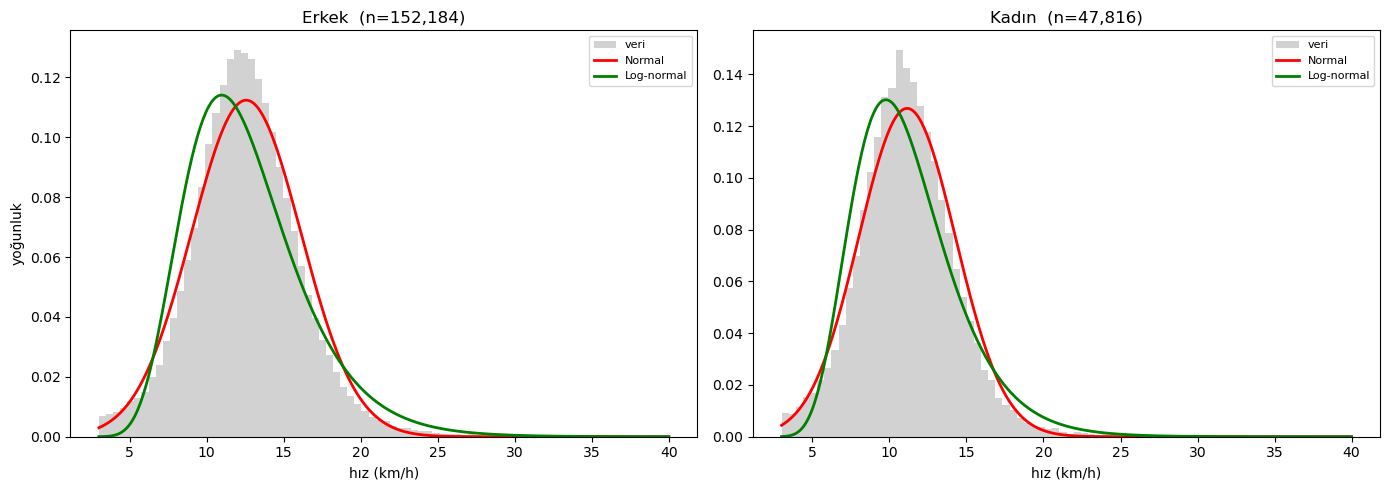

In [18]:
import duckdb, numpy as np, matplotlib.pyplot as plt
from scipy import stats as st

samp = duckdb.sql(
    "SELECT gender, speed_kmh FROM 'gender_speed.parquet' USING SAMPLE 200000 ROWS"
).df()
labels = {1: "Erkek", 2: "Kadın"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
xs = np.linspace(samp.speed_kmh.min(), samp.speed_kmh.max(), 400)

fits_def = {
    "Normal":     (st.norm,        lambda d: st.norm.fit(d)),
    "Log-normal": (st.lognorm,     lambda d: st.lognorm.fit(d, floc=0)),
}
colors = {"Normal": "red", "Log-normal": "green"}

for ax, g in zip(axes, [1, 2]):
    d = samp.loc[samp.gender == g, "speed_kmh"].values
    ax.hist(d, bins=80, density=True, alpha=0.35, color="gray", label="veri")

    # Her dağılımı uydurup histogram üzerine çiz (yalnızca görsel karşılaştırma)
    for name, (dist, fit_fn) in fits_def.items():
        par = fit_fn(d)
        ax.plot(xs, dist.pdf(xs, *par), color=colors[name], lw=2, label=name)

    ax.set_title(f"{labels[g]}  (n={len(d):,})")
    ax.set_xlabel("hız (km/h)")
    ax.legend(fontsize=8)

axes[0].set_ylabel("yoğunluk")
plt.tight_layout()
plt.show()